# IN1160 – Oblig 3a: Beslutningstrær og maskinlæring i praksis

## Innlevering

Oppgaven leveres innen 15. april klokken 23.59 i [Devilry](https://devilry.ifi.uio.no/).

Innleveringen skal bestå av én Jupyter notebook med både kode og tilhørende forklaringer. **Før innlevering skal du kjøre gjennom hele notebooken, før du lagrer siste gang. Den bør kjøre uten å feile og vise den grafikken og de utskriftene som skal være med.**

Vi understreker at innlevering av kode alene ikke er nok for å bestå oppgaven – vi forventer at notebooken også skal inneholde kommentarer (på norsk eller engelsk) på hva dere har gjort og begrunnelser for valgene dere har tatt underveis.
La enhver oblig bli en trening i å formidle forskning. Bruk helst hele setninger, og matematiske formler om nødvendig. Resultater skal presenteres i tabeller på en oversiktlig måte.
Det å forklare med egne ord, bruke begreper vi har gått gjennom på forelesningene og å forklare og reflektere over løsningene deres er en viktig del av læringsprosessen – ta det på alvor!

Når det gjelder bruk av generative prateroboter (ChatGPT og lignende): Dere kan bruke dem som en "sparringspartner", for eksempel for å forklare noe dere ikke helt har forstått. Dere har imidlertid ikke lov til å bruke dem til å generere løsninger (enten delvis eller fullstendig) til noen av oppgavene. Funksjoner for automatisk skriving av kode, som Copilot i VS Code, må derfor også være deaktivert mens dere jobber på obligen.

Bruker dere KI-verktøy vil vi også at dere kort beskriver hvordan dere har brukt dem under arbeidet med oppgaven.

Det er ikke mulighet for omlevering av obliger som ikke bestås.

Her dere spørsmål til obligen eller finner noe dere tror er feil, må dere gjerne si ifra på [Discourse](https://discourse.uio.no/c/in1160-26v/820).



## Introduksjon

I denne obligen skal vi jobbe med [Titanic-datasettet](https://www.kaggle.com/competitions/titanic/data). Dette datasettet består av informasjon om passasjerene på Titanic, som kjønn, alder og deres billettpris, samt om de overlevde eller ikke. Målet vårt er å bruke ulike maskinlæringsmodeller til å predikere om en passasjer var sannsynlig til å overleve, basert på de andre trekkene i datasettet. Var det at "kvinner og barn først" eller var det første-klasse-passasjerer som hadde størst sjanse til å overleve?

Datasettet har flere kolonner, men vi skal fokusere på de følgende:

| Kolonnenavn | Beskrivelse                                                                              |
| ----------- | ---------------------------------------------------------------------------------------- |
| 'survived'  | Angir om passasjeren overlevde (1) eller døde (0)                                        |
| 'pclass'    | Angir passasjerens billettklasse, altså 1.-klasse (1), 2.-klasse (2) eller 3.-klasse (3) |
| 'sex'       | Mann (male) eller kvinne (female)                                                        |
| 'age'       | Alder i år                                                                               |
| 'fare'      | Passasjerens billettpris                                                                 |
| 'embarked'  | Angir om passasjeren reiste fra Southampton (S) eller Cherbourg (C) eller Queenstown (Q) |
| 'sibsp'     | Antall søsken/ektefelle passasjeren hadde ombord                                         |
| 'parch'     | Antall foreldre/barn passasjeren hadde ombord                                            |


I første omgang skal vi benytte oss av beslutningstrær, før vi sammenligner disse med andre algoritmer, som _k_-NN og nevrale nettverk.


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import load_dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

### Frysing av tilfeldigheter

I cellen under setter vi NumPy sitt "seed" til tallverdien 1160. NumPy bruker mange "tilfeldige" verdier.
Ingenting er helt tilfeldig i datamaskiner, så disse verdiene blir valgt basert på algoritmer som skal simulere tilfeldighet. Algoritmene velger basert på et slikt seed, men dette vil endre seg fra kjøring til kjøring, så ved å "fryse" dette vil vi kunne få samme resultater for hver kjøring.  
Å gjøre dette er nyttig for oss når vi utvikler programmer, så vi får bedre oversikt over hva som skjer fra en gang til neste, men det er også viktig i vitenskapelig arbeid, siden det gjør resultatene våre etterprøvbare. 

Å fryse NumPy-tilfeldigheter er et viktig første steg, men mange av metodene, f.eks. `train_test_split()`, og klassene, f.eks. `DecisionTreeClassifier`, fra scikit-learn vi bruker i denne obligen bruker egne seeds. Disse har en ikke-obligatorisk parameter `random_state` som kan settes til et bestemt tall. 
En del av denne obligen blir å sørge for at alle metoder og klasser som har denne parameteren initialiseres med `random_state=1160`. Den beste kilden for å finne ut av disse parameterne er [den offisielle dokumentasjonen for scikit-learn](https://scikit-learn.org/stable/api/index.html). 


In [68]:
print("Før frysing:", np.random.randint(0, 1000), "(uforutsigbart)")
np.random.seed(1160)
print("Etter frysing:", np.random.randint(0, 1000), "(bør bli 373)")

Før frysing: 363 (uforutsigbart)
Etter frysing: 373 (bør bli 373)


## Oppgave 1

### Oppgave 1.1 – Forberede datasett (2 poeng)

Her laster vi inn datasettet ved bruk av funksjonen `load_dataset()`. Dette gir oss en `pandas.DataFrame` med dataene. 
Denne består stort sett av numeriske data, men kolonnene 'sex' og 'embarked' har strenger som verdier. Disse må gjøres om til numeriske verdier før vi kan bruke dem i modellene våre. For eksempel kan vi gjøre om 'male' til 0 og 'female' til 1. Til dette kan dere bruke metoden `.map()`.

I tillegg mangler noen av radene en verdi. Dette gjelder 'age'-kolonnen og 'embarked'-kolonnen. 
For å håndtere dette skal vi for 'age' fylle inn manglende verdier med medianalderen til alle passasjerene. Her kan metodene `.median()` og `.fillna()` være nyttige. 
For 'embarked' skal vi fylle inn manglende verdier med det mest vanlige utfartsstedet.

I denne oppgaven skal dere:
- Hente ut de relevante kolonnene fra datasettet (gjengitt i `wanted_features`).
- Gjøre om kategoriske data til numeriske verdier.
- Fylle inn manglende verdier som beskrevet over.
- Hente ut målkategorien 'survived'.

Hvis dere trenger hjelp med å jobbe med `DataFrames` kan dere ta en kikk på [pandas-dokumentasjonen](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html). Dere kan også se på [denne introduksjonen](../../ressurser/uke01-introduksjon/01bonus_pandas_plotly_tutorial.ipynb).

In [69]:
# Oppgave 1.1
df = load_dataset('titanic')
wanted_features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'sibsp', 'parch']

df_wanted_features = df[wanted_features]
df_wanted_features["sex"] = df_wanted_features["sex"].map({"male" : 0, "female" : 1})
df_wanted_features["embarked"] = df_wanted_features["embarked"].map({"S" : 0, "C" : 1, "Q" : 2})
df_wanted_features = df_wanted_features.fillna({"age" : df_wanted_features["age"].median(), 
                                                "embarked" : df_wanted_features["embarked"].mode()[0]})

df_survived = df["survived"]

### Oppgave 1.2 – Oppdeling av datasett (1 poeng)

Dere skal nå dele opp i en treningssplitt og en testsplitt. Dere kan bruke `train_test_split()` til dette. Skriv så ut størrelsen av de to splittene.  
Vi skal bruke 80% av dataene til trening og 20% som testdata.

Husk å sette `random_state`! 

In [70]:
# Oppgave 1.2
x_train, x_test = train_test_split(df_wanted_features, train_size=0.8, random_state=1160)
y_train, y_test = train_test_split(df_survived, train_size=0.8, random_state=1160)

## Oppgave 2 – Tre-trening

### Oppgave 2.1 – Et ubegrenset tre (2 poeng)

Vi skal trene en `DecisionTreeClassifier`. Her skal dere ikke ta noen form for hensyn til høyde på treet eller andre typer regularisering.

I denne oppgaven skal dere:

1. Opprette en `DecisionTreeClassifier` og trene den med `.fit()`.
2. Finne ut hvor høyt treet blir og hvor mange løvnoder det får.
3. Gjøre prediksjoner på både trenings- og testsett.
4. Beregne nøyaktighet for treet på begge splittene. Rapporter resultatene i en markdown-celle med en kort kommentar om hva vi observerer.

In [ ]:
# Oppgave 2.1
classifier = DecisionTreeClassifier()
classifier.fit(X=x_train, y=y_train)
print("Treets dybde: " + str(classifier.get_depth()))
print("Antall løvnoder: " + str(classifier.get_n_leaves()))
train_predictions = classifier.predict(X=x_train)
test_predictions = classifier.predict(X=x_test)
print("Nøyaktighet av treningssettet: " + str(accuracy_score(y_train, train_predictions)))
print("Nøyaktighet av testsettet: " + str(accuracy_score(y_test, test_predictions)))

Treets dybde: 20
Antall løvnoder: 158
Nøyaktighet av treningssettet: 0.9831460674157303
Nøyaktighet av testsettet: 0.776536312849162


#### Oppgave 2.1 – Tekstbesvarelse

_Hva ser dere av resultatene?_

**Svar:**
Treet får høye verdier av dybden og antall løvnoder, med henholdsvis 20 og 158. Det får en veldig høy nøyaktighet på treningssettet, og en passe god verdi på testsettet.


### Oppgave 2.2 – Visualisering (1 poeng)

Under har vi implementert en enkel plotting for beslutningstrær. Denne tar inn et trent tre og lista over trekkene som ble brukt under trening. Den har også et ikke-obligatorisk parameter `max_depth` som er satt til 3. Dette er for å unngå visualiseringer av trær med veldig mange løvnoder.

Her skal dere gjøre en visualisering av treet med `max_depth` fortsatt på 3. Beskriv hva dere ser. Kan vi bruke treet til å fastslå hva majoritetsklassen er? Hvilke trekk benytter modellen seg av først? 

In [72]:
def visualize_tree(decision_tree, column_names, max_depth=3):
    plt.figure(figsize=(16, 8))
    plot_tree(
        decision_tree,
        max_depth=max_depth,
        feature_names=column_names,
        class_names=['died', 'survived'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Decision Tree with max depth {decision_tree.get_depth()}")
    plt.tight_layout()
    plt.show()

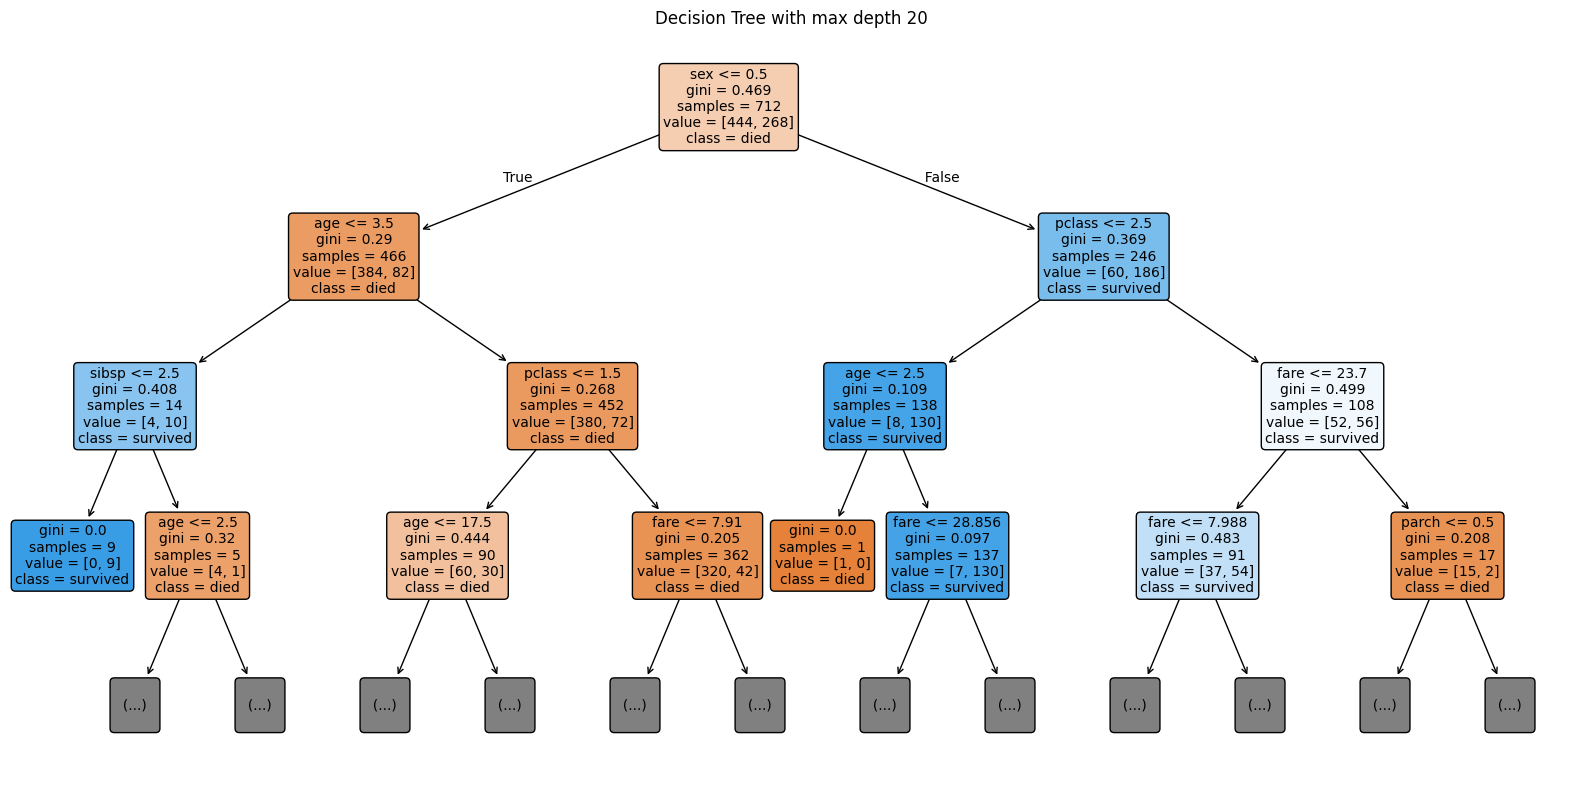

In [73]:
# Oppgave 2.2
visualize_tree(classifier, x_train.columns)

#### Oppgave 2.2 – Tekstbesvarelse

_Hva ser dere av treet?_

**Svar:** Treet sjekker først kjønnet til passasjerene, så det er trekket som er vitkigst i å bestemme hvem som overlevde.

### Oppgave 2.3 – Regularisering (3 poeng)

Dere skal nå lage nye trær med begrenset høyde. Bruk høydene spesifisert i lista `tree_depths` til å trene trær. Lag en tabell der dere for hver høyde noterer resultatene for nøyaktighet for både treningsdataene og testdataene, samt hvor mange løvnoder hvert tre får.


In [87]:
# Oppgave 2.3
tree_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, None]
results = {}

for i, depth in enumerate(tree_depths):
    classifier = DecisionTreeClassifier(max_depth=depth)
    classifier.fit(X=x_train, y=y_train)
    train_predictions = classifier.predict(X=x_train)
    test_predictions = classifier.predict(X=x_test)
    results[depth] = {}
    results[depth]["Trening nøyaktighet"] = accuracy_score(y_train, train_predictions)
    results[depth]["Test nøyaktighet"] = accuracy_score(y_test, test_predictions)
    results[depth]["Antall løvnoder"] = classifier.get_n_leaves()

results_df = pd.DataFrame(results)
print(results_df.T)

      Trening nøyaktighet  Test nøyaktighet  Antall løvnoder
2.0              0.808989          0.743017              4.0
3.0              0.832865          0.782123              8.0
4.0              0.839888          0.770950             14.0
5.0              0.856742          0.787709             22.0
6.0              0.866573          0.787709             32.0
7.0              0.891854          0.765363             45.0
8.0              0.897472          0.787709             58.0
9.0              0.922753          0.770950             75.0
10.0             0.939607          0.776536             91.0
15.0             0.974719          0.770950            141.0
NaN              0.983146          0.770950            158.0


### Oppgave 2.4 – Kryssvalidering (2 poeng)

Så langt har vi delt dataene våre én gang i trenings- og testsett. Av og til kan vi være uheldige og få en oppdeling som får modellen vår til å se bedre (eller dårligere) ut enn den egentlig er. Vi kan løse dette med _kryssvalidering_ (engelsk: cross-validation) av dataene.  

Under kryssvalidering deler vi opp dataene flere ganger på forskjellige måter, slik at hver del av datasettet får prøvd seg som både treningssplitt og testsplitt. Vi trener modellen tilsvarende antall ganger og kommer fram til vårt endelige svar ved å ta gjennomsnittet av resultatene.
Dette gir oss et mer pålitelig estimat av ytelsen enn én enkelt trenings-test-oppdeling.

Dere skal nå bruke `cross_val_score()` til å utføre fem-gangers kryssvalidering på et beslutningstre uten noen høydebegrensning. Antall biter vi ønsker å dele treningssettet opp i styres av parameteren `cv`. I tillegg må dere sette parameteren `scoring` til 'accuracy', ettersom vi bruker nøyaktighet som målestokk.  
Etter å ha gjort dette skal dere beregne og skrive ut gjennomsnittet og standardavviket for de fem oppdelingene.


In [86]:
# Oppgave 2.4
classifier = DecisionTreeClassifier()
kryssvalidering = cross_val_score(classifier, X=df_wanted_features, y=df_survived, cv=5, scoring="accuracy")
print("Gjennomsnittlig nøyaktighet: " + str(np.mean(kryssvalidering)))
print("Standardavvik av nøyaktighet: " + str(np.std(kryssvalidering)))

Gjennomsnittlig nøyaktighet: 0.7755821982298663
Standardavvik av nøyaktighet: 0.03775072087433061


### Oppgave 2.5 – Trehøyde med kryssvalidering (2 poeng)

Dere skal nå teste forskjellige trehøyder/tredybder ved hjelp av kryssvalidering.  
Dette gjør dere ved å:

1. Gå gjennom de forskjellige `max_depth`-verdiene i `tree_depths`.
2. Utføre kryssvalidering for hver dybde.
3. Registrere gjennomsnittlig kryssvalidering.

Til slutt skal dere trene et siste tre der dere bruker den beste dybdeparameteren dere fant. Dere skal nå trene på hele treningssettet og teste mot de originale testdataene. Rapporter nøyaktighet for både treningsdataene og testdataene.

In [88]:
# Oppgave 2.5
tree_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, None]
depth_crossevaluation = {}

for i, depth in enumerate(tree_depths):
    classifier = DecisionTreeClassifier(max_depth=depth)
    depth_crossevaluation[depth] = np.mean(cross_val_score(classifier, X=df_wanted_features, y=df_survived, cv=5, scoring="accuracy"))

In [93]:
best_depth = max(depth_crossevaluation, key=depth_crossevaluation.get)
classifier = DecisionTreeClassifier(max_depth=best_depth)
classifier.fit(X=x_train, y=y_train)
train_predictions = classifier.predict(X=x_train)
test_predictions = classifier.predict(X=x_test)
print("Nøyaktighet for beste dybdeparameter for treningsdata: " + str(accuracy_score(y_train, train_predictions)))
print("Nøyaktighet for beste dybdeparameter for testdata: " + str(accuracy_score(y_test, test_predictions)))

Nøyaktighet for beste dybdeparameter for treningsdata: 0.8665730337078652
Nøyaktighet for beste dybdeparameter for testdata: 0.7932960893854749


### Oppgave 2.6 – Tilfeldige skoger (3 poeng)

Vi skal nå undersøke effekten av å bruke tilfeldige skoger (engelsk: _random forests_).
Dette er en såkalt ensemble-metode hvor vi oppretter en skog, altså mange trær, og lar dem "stemme" om svaret, i stedet for å stole på ett enkelt beslutningstre.  
For å gjøre dette skal vi bruke en `RandomForestClassifier` som skal bestå av 100 trær. Bruk den beste verdien for `max_depth` dere fant i forrige oppgave. 

Lag skogen med 100 trær, tren den og gjør prediksjoner. Hva er differansen på nøyaktighet mellom skogmodellen og treet med best høyde fra oppgaven over?

In [94]:
# Oppgave 2.6
classifier = RandomForestClassifier(n_estimators=100, max_depth=best_depth)
classifier.fit(X=x_train, y=y_train)
predictions = classifier.predict(X=x_test)
print("Nøyaktighet for skogen: " + str(accuracy_score(y_test, predictions)))

Nøyaktighet for skogen: 0.8044692737430168


**Svar:** Treet ga en nøyaktighet på 0.793, mens skogen ga en nøyaktighet på 0.804, et litt bedre resultat

### Oppgave 2.7 – Skogbredde (2 poeng)

På samme måte som med dybde, kan vi undersøke hvor mange trær det er gunstig å bruke.  
Bruk verdiene i `n_trees_list` til å undersøke hvordan nøyaktigheten endrer seg basert på hvor mange trær vi har. Her skal dere bruke kryssvalidering på samme måte som i oppgave **2.5**. Også her skal dere avslutningsvis trene en skog med de beste parameterne og alle treningsdataene, før dere måler ytelse på testsettet. 

In [96]:
# Oppgave 2.7
n_trees_list = [1, 5, 10, 20, 35, 50, 75, 100, 200, 500, 1000]
trees_crossevaulation = {}

for trees in n_trees_list:
    classifier = RandomForestClassifier(n_estimators=trees, max_depth=best_depth)
    trees_crossevaulation[trees] = np.mean(cross_val_score(classifier, X=df_wanted_features, y=df_survived, cv=5, scoring="accuracy"))


In [97]:
best_trees = max(trees_crossevaulation, key=trees_crossevaulation.get)
classifier = RandomForestClassifier(n_estimators=best_trees, max_depth=best_depth)
classifier.fit(X=x_train, y=y_train)
predictions = classifier.predict(X=x_test)
print("Nøyaktighet for beste antall trær: " + str(accuracy_score(y_test, predictions)))

Nøyaktighet for beste antall trær: 0.8044692737430168


## Oppgave 3 – Måle mot andre modeller

I denne oppgaven skal vi sammenligne beslutningstrær med to andre modeller vi allerede har vært innom: _k_-NN og nevrale nettverk.

### Oppgave 3.1 – _k_-NN (2 poeng)

Her skal dere lage en _k_-NN-modell med `KNeighborsClassifier` som i oblig 1b. 

Her skal dere:

1. Finne den beste verdien for _k_ blant verdiene listet i `k_values`.
2. Gjøre prediksjoner og beregne nøyaktighet for både trenings- og testsett.
3. Rapportere resultatene i en markdown-celle.
4. Sammenligne resultatene med den beste skogen fra oppgave **2.7**.


In [99]:
# Oppgave 3.1
k_values = [1, 3, 5, 7, 10, 15, 20, 30, 50, 100]
k_crossevaluation = {}

for k in k_values:
    classifier = KNeighborsClassifier(n_neighbors=k)
    #Antas her at kryssvalidering skal brukes for å finne beste k-verdi
    crossevalution = cross_val_score(classifier, X=df_wanted_features, y=df_survived, cv=5, scoring="accuracy")
    k_crossevaluation[k] = np.mean(crossevalution)

best_k = max(k_crossevaluation, key=k_crossevaluation.get)
classifier = KNeighborsClassifier(n_neighbors=k)
classifier.fit(X=x_train, y=y_train)
train_predictions = classifier.predict(X=x_train)
test_predictions = classifier.predict(X=x_test)
print("Nøyaktighet for beste k for treningsdata: " + str(accuracy_score(y_train, train_predictions)))
print("Nøyaktighet for beste k for testdata: " + str(accuracy_score(y_test, test_predictions)))

Nøyaktighet for beste k for treningsdata: 0.6896067415730337
Nøyaktighet for beste k for testdata: 0.6256983240223464


**Svar:** Vi får en nøyaktighet på 0.626 for en k-NN-modell, som viser at dette er en langt mindre nøyaktig modell enn besluttningstremodellen.

### Oppgave 3.2 – Nevrale nettverk (2 poeng)

Dere skal nå lage en modell med et nevralt nettverk ved hjelp av `MLPClassifier`. Denne ligner langt på vei på den nevrale nettverksklassen dere benyttet dere av i oblig 2b, men har noen små forskjeller det kan være lurt å være klar over:

- De ulike lagene spesifiseres med parameteren `hidden_layer_sizes`. Denne tar en tuppel med antall noder i hvert lag, som f.eks. `(5, 10, 8)` for tre lag med henholdsvis 5, 10 og 8 noder.
- Aktiveringsfunksjonen spesifiseres med parameteren `activation`. Standardverdien for denne er `'relu'`. Denne implementasjonen kan bare bruke én aktiveringsfunksjon for alle lagene.
- Trening skjer som vanlig med metoden `.fit()`.

Her skal dere finne den beste sammensetningen av lag fra lista `hidden_sizes`. I denne oppgaven trenger dere ikke å gjøre kryssvalidering.
Sammenlign resultatene av det beste nevrale nettverket med de to andre modellene dere har laget så langt.


In [100]:
# Oppgave 3.2
hidden_sizes = [
    (5,),
    (10,),
    (50,),
    (100,),
    (25, 25),
    (50, 50),
    (25, 100, 25)
]

best_accuracy = 0
best_layers = ()
for layers in hidden_sizes:
    neural_network_classifier = MLPClassifier(hidden_layer_sizes=layers)
    X = neural_network_classifier.fit(X=x_train, y=y_train)
    predictions = neural_network_classifier.predict(X=x_test)
    if accuracy_score(y_test, predictions) > best_accuracy:
        best_accuracy = accuracy_score(y_test, predictions)
        best_layers = layers

print("Beste nøyaktighet: " + str(best_accuracy))
print("Beste antall noder: " + str(best_layers))

c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimiza

Beste nøyaktighet: 0.7653631284916201
Beste antall noder: (50,)


### Oppgave 3.3 – Et sammensatt ensemble (2 poeng)

Vi har allerede undersøkt hvordan skoger av trær kan forbedre nøyaktigheten til beslutningstrær. 
I denne oppgaven skal vi videreutvikle vårt ensemble og kombinere skogen med de to andre modellene vi har laget.

For å gjøre dette skal dere bruke `VotingClassifier` fra scikit-learn. Denne klassen tar inn flere modeller i form av tupler på formatet `(navn, modell)`, der navn er en streng og modell er en klassifikasjonsmodell med de parameterne vi ønsker å bruke. 

Her skal dere sende inn en `KNeighborsClassifier`, en `MLPClassifier` og en `RandomForestClassifier`. Alle disse skal ha de beste parameterne dere har funnet i de foregående oppgavene.  
Tren så ensemble-modellen på treningsdataene (ingen kryssvalidering) og gjør prediksjoner på både trenings- og testdataene.

Beregn nøyaktighet på begge to og rapporter resultatene i en markdown-celle. Hvilken modell gjorde det best?


In [102]:
# Oppgave 3.3
classifier = VotingClassifier(estimators=[("KNeighborsClassifier", KNeighborsClassifier(best_k)), ("MLPClassifier", MLPClassifier(hidden_layer_sizes=best_layers)), 
                             ("RandomForestClassifier", RandomForestClassifier(n_estimators=best_trees))])

X = classifier.fit(X=x_train, y=y_train)
train_predictions = classifier.predict(X=x_train)
test_predictions = classifier.predict(X=x_test)
print("Nøyaktighet for treningsdataen: " + str(accuracy_score(y_train, train_predictions)))
print("Nøyaktighet for testdataen: " + str(accuracy_score(y_test, test_predictions)))


Nøyaktighet for treningsdataen: 0.9002808988764045
Nøyaktighet for testdataen: 0.8156424581005587


c:\Users\af64\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


**Svar:**
|Modell|Nøyaktighet|
|-----|-------------|
|k-NN-modell|0.626|
|Beslutningstrær|0.793|
|Tilfeldig skog|0.804|
|Nevralt Nettverk|0.765|
|Sammensatt ensemble|0.816|

Vi ser av tabellen at det sammensatte ensemble gir best resultat, noe som er forventet, da denne modellen bruker flere andre modeller for å få best resultat. Sett bort fra den nå gir en tilfeldig skog det beste resultatet, som viser at beslutningstrær er best for å gi prediksjoner for dette datasettet.